In [1]:
import time_utils
import numpy as np
import matplotlib.pyplot as plt

### Análisis de Tiempos de Ejecución
Este código realiza un análisis estadístico de tiempos de ejecución

[17.77, 20.6, 19.59, 19.97, 19.33, 23.97, 19.97, 19.33, 23.97, 20.91, 22.16, 18.34, 21.05, 23.77, 18.56, 21.05, 19.2, 24.12, 17.76, 22.04, 15.62, 23.55, 21.65, 24.25, 20.33, 26.44, 23.31, 21.22, 28.32, 22.11]

Media estimada: 21.34
Intervalo de confianza al 95%: (20.37, 22.34)


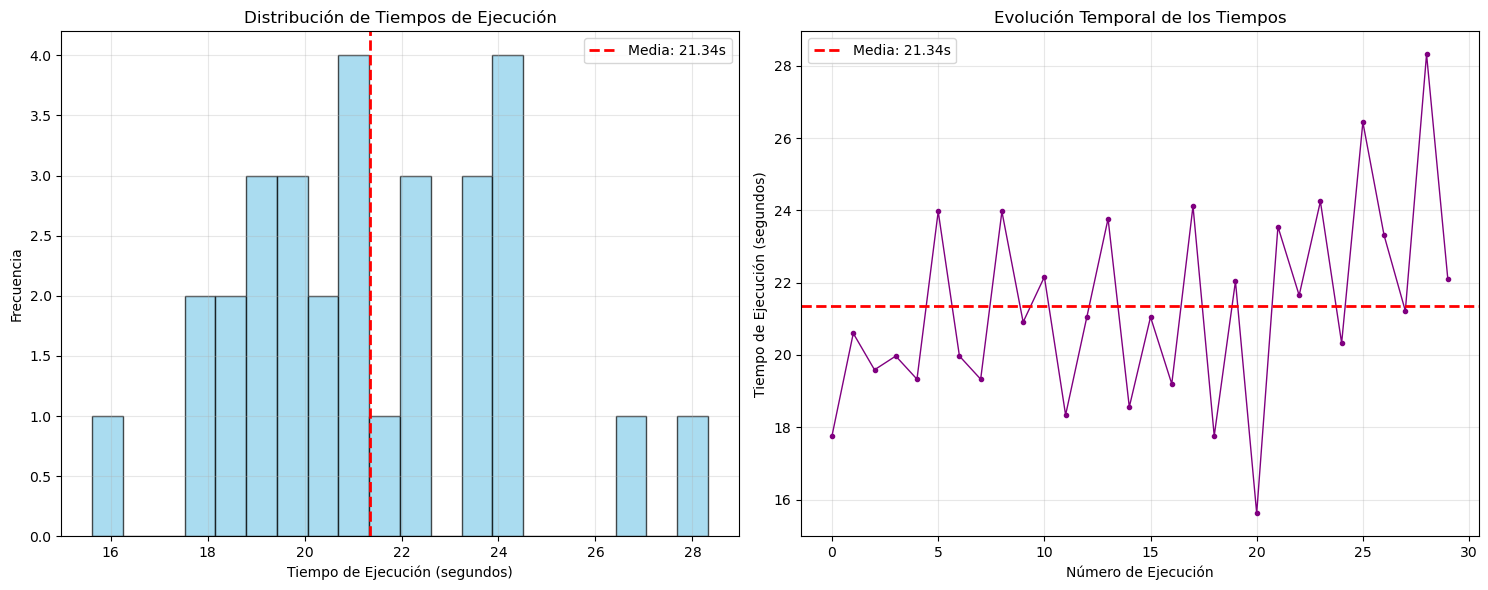

In [2]:
times = time_utils.get_execution_times("results.json")
print(times)
print()

varianza_estimada = np.var(times, ddof=1)
resultado = time_utils.media_intervalo_confianza(times)
media_estimada = resultado["media_poblacional_estimada"]
print("Media estimada:", round(media_estimada, 2))
print("Intervalo de confianza al 95%:", resultado["intervalo_confianza"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histograma de tiempos de ejecución
axes[0].hist(times, bins=20, alpha=0.7, color='skyblue', edgecolor='black')
axes[0].axvline(media_estimada, color='red', linestyle='--', linewidth=2, label=f'Media: {media_estimada:.2f}s')
axes[0].set_xlabel('Tiempo de Ejecución (segundos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Tiempos de Ejecución')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Gráfico de línea temporal (si hay orden temporal)
axes[1].plot(range(len(times)), times, marker='o', linewidth=1, markersize=3, color='purple')
axes[1].axhline(media_estimada, color='red', linestyle='--', linewidth=2, label=f'Media: {media_estimada:.2f}s')
axes[1].set_xlabel('Número de Ejecución')
axes[1].set_ylabel('Tiempo de Ejecución (segundos)')
axes[1].set_title('Evolución Temporal de los Tiempos')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



Ahora analizaremos los tiempos de respuesta cuando la búsqueda requiere buscar en la web 

Tiempos de ejecución con búsqueda web:
[48.77, 50.44, 60.22, 45.55, 47.33, 46.57, 48.88, 59.11, 52.32, 54.91, 56.16, 57.78, 58.67, 62.12, 57.56, 60.15, 63.22, 55.37, 58.9, 50.56, 57.34, 49.22, 55.23, 52.67, 52.27, 55.56, 60.53, 49.32, 58.32, 52.11]

Media estimada: 54.58
Intervalo de confianza al 95%: (52.82, 56.32)


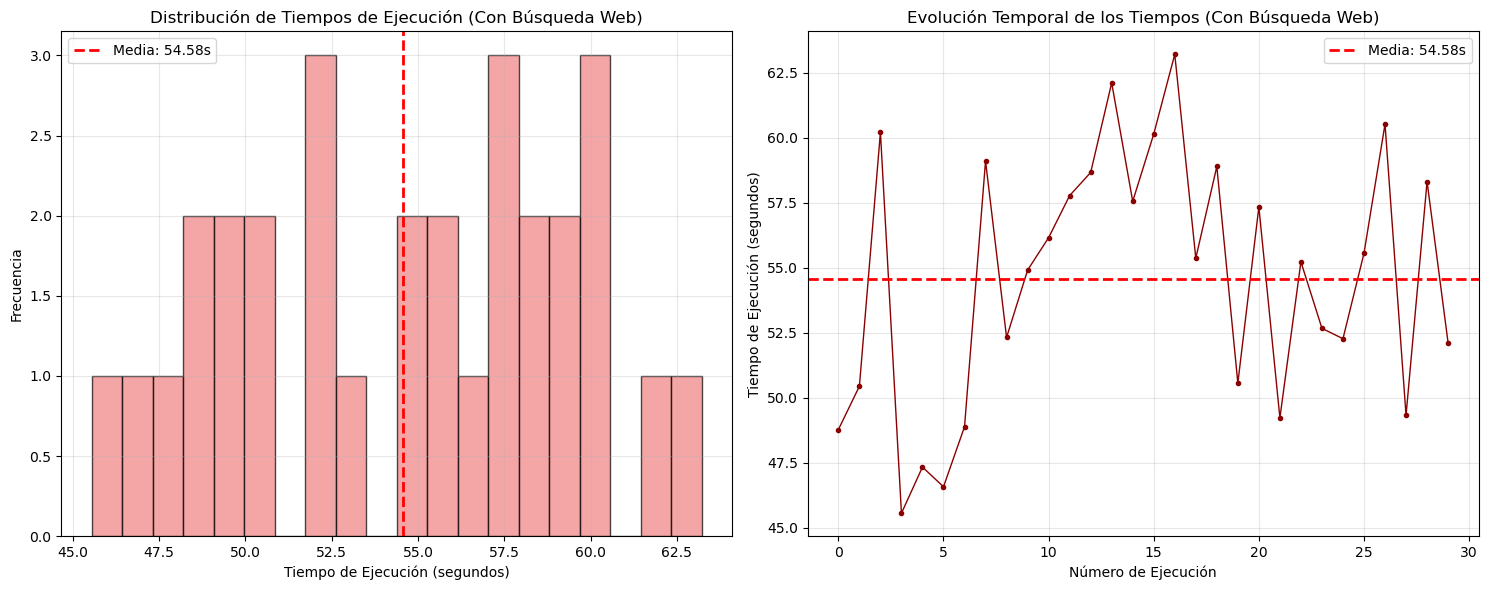


COMPARACIÓN: BÚSQUEDA LOCAL vs BÚSQUEDA WEB
Media sin web: 21.34s
Media con web: 54.58s
Diferencia: 33.23s (155.70% más lento)
Varianza sin web: 7.51
Varianza con web: 24.32


In [3]:
# Análisis de tiempos para búsquedas web (crawler)
# Cargar datos del crawler (tiene estructura diferente)

times_crawler = time_utils.get_execution_times("results_crawler.json")
print("Tiempos de ejecución con búsqueda web:")
print(times_crawler)
print()

varianza_estimada_crawler = varianza_muestral = np.var(times_crawler, ddof=1)
resultado = time_utils.media_intervalo_confianza(times_crawler)
media_estimada_crawler = resultado["media_poblacional_estimada"]
print("Media estimada:", round(media_estimada_crawler, 2))
print("Intervalo de confianza al 95%:", resultado["intervalo_confianza"])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Histograma de tiempos de ejecución con crawler
axes[0].hist(times_crawler, bins=20, alpha=0.7, color='lightcoral', edgecolor='black')
axes[0].axvline(media_estimada_crawler, color='red', linestyle='--', linewidth=2, label=f'Media: {media_estimada_crawler:.2f}s')
axes[0].set_xlabel('Tiempo de Ejecución (segundos)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de Tiempos de Ejecución (Con Búsqueda Web)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Gráfico de línea temporal para crawler
axes[1].plot(range(len(times_crawler)), times_crawler, marker='o', linewidth=1, markersize=3, color='darkred')
axes[1].axhline(media_estimada_crawler, color='red', linestyle='--', linewidth=2, label=f'Media: {media_estimada_crawler:.2f}s')
axes[1].set_xlabel('Número de Ejecución')
axes[1].set_ylabel('Tiempo de Ejecución (segundos)')
axes[1].set_title('Evolución Temporal de los Tiempos (Con Búsqueda Web)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Comparación entre ambos conjuntos de datos
print("\n" + "="*60)
print("COMPARACIÓN: BÚSQUEDA LOCAL vs BÚSQUEDA WEB")
print("="*60)
print(f"Media sin web: {media_estimada:.2f}s")
print(f"Media con web: {media_estimada_crawler:.2f}s")
print(f"Diferencia: {media_estimada_crawler - media_estimada:.2f}s ({((media_estimada_crawler/media_estimada - 1) * 100):.2f}% más lento)")
print(f"Varianza sin web: {varianza_estimada:.2f}")
print(f"Varianza con web: {varianza_estimada_crawler:.2f}")